## ML Lab Internal Exam - SET 1
## Name: Md Zameer
## ID: b200926
## Class:cse-C4

## Dataset Description
The classification task of this database is to determine where patients in a postoperative recovery area (after a operation) should be sent to next. Because hypothermia is a significant concern after surgery (Woolery, L. et. al. 1991), the attributes correspond roughly to body temperature measurements. 


<b>Attribute Information:</b><br>

1. L-CORE (patient's internal temperature in C): <br>
high (> 37), mid (>= 36 and <= 37), low (< 36) <br>
2. L-SURF (patient's surface temperature in C): <br>
high (> 36.5), mid (>= 36.5 and <= 35), low (< 35) <br>
3. L-O2 (oxygen saturation in %): <br>
excellent (>= 98), good (>= 90 and < 98), fair (>= 80 and < 90), poor (< 80) <br>
4. L-BP (last measurement of blood pressure): <br>
high (> 130/90), mid (<= 130/90 and >= 90/70), low (< 90/70) <br> 
5. SURF-STBL (stability of patient's surface temperature): <br>
stable, mod-stable, unstable <br>
6. CORE-STBL (stability of patient's core temperature) <br>
stable, mod-stable, unstable <br>
7. BP-STBL (stability of patient's blood pressure) <br>
stable, mod-stable, unstable <br>
8. COMFORT (patient's perceived comfort at discharge, measured as an integer between 0 and 20) <br>
9. decision ADM-DECS (discharge decision): <br>
I  (patient sent to Intensive Care Unit), <br>
S (patient prepared to go home), <br>
A (patient sent to general hospital floor)

In [202]:
# Import necessary libraries
import numpy as np
import pandas as pd
import seaborn as sbn
import matplotlib.pyplot as plt

In [203]:
#Import Dataset - set1_data.csv 
df=pd.read_csv("/home/rgukt-basar/aaaaa/set1_data.csv")


In [204]:
# Print top 5 and random 5 values - 2 Marks
df.head()

,L-CORE,L-SURF,L-O2,L-BP,SURF-STBL,CORE-STBL,BP-STBL,COMFORT,ADM-DECS
0,mid,low,excellent,mid,stable,stable,stable,15.0,A
1,mid,high,excellent,high,stable,stable,stable,10.0,S
2,high,low,excellent,high,stable,stable,mod-stable,10.0,A
3,mid,low,good,high,stable,unstable,mod-stable,15.0,A
4,mid,mid,excellent,high,stable,stable,stable,10.0,A


In [205]:
#Print column names - 1 Marks
#df.columns
df.columns.to_list()

['L-CORE',
 'L-SURF',
 'L-O2',
 'L-BP',
 'SURF-STBL',
 'CORE-STBL',
 'BP-STBL',
 'COMFORT',
 'ADM-DECS']

In [206]:
#Check the data type of each column - 1 Marks
df.dtypes

L-CORE        object
L-SURF        object
L-O2          object
L-BP          object
SURF-STBL     object
CORE-STBL     object
BP-STBL       object
COMFORT      float64
ADM-DECS      object
dtype: object

In [207]:
#Print number of rows and columns 1 Mark
print("number of rows and columns are :",df.shape[0]," x ",df.shape[1])

number of rows and columns are : 90  x  9


In [208]:
#Print summary statistics of all variables - 1 Mark
df.describe()

,COMFORT
count,87.000000
mean,10.942529
std,2.304477
min,5.000000
25%,10.000000
50%,10.000000
75%,10.000000
max,15.000000


In [209]:
#Print the number of missing values in each column - 1 Marks
df.isnull().sum()

L-CORE       1
L-SURF       0
L-O2         1
L-BP         0
SURF-STBL    1
CORE-STBL    0
BP-STBL      0
COMFORT      3
ADM-DECS     0
dtype: int64

In [210]:
#Impute missing values - Replace missing categorical values with mode and numerical values with mean of the column - 3 Mark
#Print the number of missing values in each column after imputation
col1=df.select_dtypes(include='object')
col2=df.select_dtypes(include='number')
for col in col1:
    df[col].fillna(df[col].mode(),inplace=True)
for col in col2:
    df[col].fillna(df[col].mode(),inplace=True)
df.isnull().sum()

L-CORE       1
L-SURF       0
L-O2         1
L-BP         0
SURF-STBL    1
CORE-STBL    0
BP-STBL      0
COMFORT      3
ADM-DECS     0
dtype: int64

In [211]:
#Print count of patients in each category - 1 Marks
df.count()

L-CORE       89
L-SURF       90
L-O2         89
L-BP         90
SURF-STBL    89
CORE-STBL    90
BP-STBL      90
COMFORT      87
ADM-DECS     90
dtype: int64

In [212]:
#Impute missing values - Replace missing categorical values with mode and numerical values with mean of the column - 3 Mark
#Print the number of missing values in each column after imputation
col1=df.select_dtypes(include='object')

(array([ 2.,  0.,  1.,  0.,  0., 65.,  0.,  0.,  0., 19.]),
 array([ 5.,  6.,  7.,  8.,  9., 10., 11., 12., 13., 14., 15.]),
 <BarContainer object of 10 artists>)

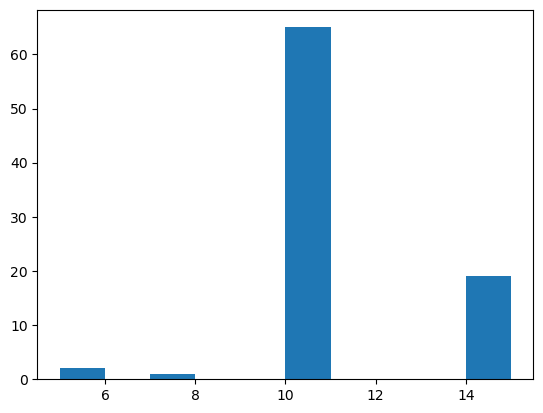

In [213]:
#Plot histogram of values of patient's perceived comfort at discharge - 1 Marks
plt.hist(df["COMFORT"])
#sbn.histplot(df["COMFORT"])

<Axes: xlabel='L-BP', ylabel='count'>

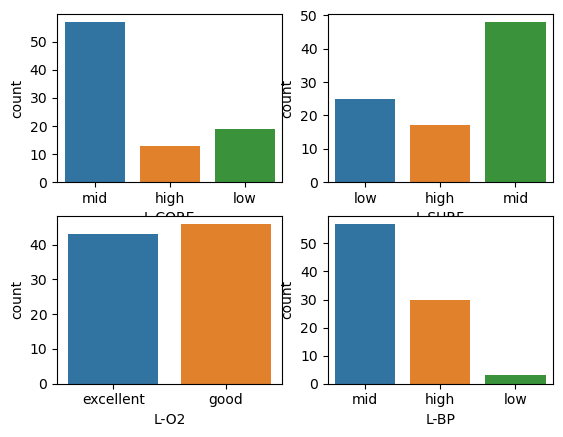

In [214]:
# Plot barchart of L-CORE, L-SURF,L-O2 and L-BP using 4X4 subplots - 3 Marks
#num_bins = 10
fig,axces=plt.subplots(2,2)
sbn.countplot(x=df['L-CORE'],ax=axces[0,0])
sbn.countplot(x=df['L-SURF'],ax=axces[0,1])
sbn.countplot(x=df['L-O2'],ax=axces[1,0])
sbn.countplot(x=df['L-BP'],ax=axces[1,1])

array([48, 25, 17])

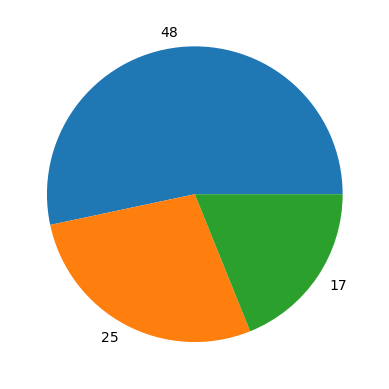

In [215]:
# Plot pie chart of patient's surface temperature in C - 2 Mark
plt.pie(df["L-SURF"].value_counts().values,labels=df["L-SURF"].value_counts())
labels=df["L-SURF"].value_counts()
labels.values

In [238]:
#Prepare X - input matrix and y - label vector - 1 Mark
x=df.drop("ADM-DECS",axis=1)
y=df["ADM-DECS"]
x

,L-CORE,L-SURF,L-O2,L-BP,SURF-STBL,CORE-STBL,BP-STBL,COMFORT
0,2,1,0,2,0,1,1,15.0
1,2,0,0,0,0,1,1,10.0
2,0,1,0,0,0,1,0,10.0
3,2,1,1,0,0,2,0,15.0
4,2,2,0,0,0,1,1,10.0
...,...,...,...,...,...,...,...,...
85,2,2,0,2,1,1,1,10.0
86,2,2,0,2,1,1,1,15.0
87,2,2,2,2,1,1,1,15.0
88,2,2,0,2,1,1,1,10.0


In [239]:
#Apply label encoder for categorical columns - 2 Marks
col1=df.select_dtypes(include='object').columns
from sklearn.preprocessing import LabelEncoder
lb=LabelEncoder()
for col in col1:
    df[col]=lb.fit_transform(df[col])
x

,L-CORE,L-SURF,L-O2,L-BP,SURF-STBL,CORE-STBL,BP-STBL,COMFORT
0,2,1,0,2,0,1,1,15.0
1,2,0,0,0,0,1,1,10.0
2,0,1,0,0,0,1,0,10.0
3,2,1,1,0,0,2,0,15.0
4,2,2,0,0,0,1,1,10.0
...,...,...,...,...,...,...,...,...
85,2,2,0,2,1,1,1,10.0
86,2,2,0,2,1,1,1,15.0
87,2,2,2,2,1,1,1,15.0
88,2,2,0,2,1,1,1,10.0


In [240]:
# Split the data into train and test set  - use test size = 30% and random state = 4 : - 2 Marks
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.3,random_state=4)
x_train.shape,x_test.shape

((63, 8), (27, 8))

In [243]:
#Print train and test data size
x_train=x_train.fillna(x_train.mean())

In [244]:
# Fit the Naive Bayes classifier on training data - 3 Marks
from sklearn.naive_bayes import GaussianNB
model=GaussianNB()
model.fit(x_train,y_train)

GaussianNB()

In [248]:
# Make prediction on test data - 1 Marks
x_test=x_test.fillna(x_test.mean())
y_p=model.predict(x_test)

In [222]:
# Check the evaluation metrics of the model - Confusion Matrix, Accuracy, Precision, Recall, F1 score - 3 Marks


In [173]:
#Apply prediction on any one sample input and print the probability estimates for each class - 1 marks
